In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from collections import Counter
from scipy.spatial import distance
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. Иерархический кластерный анализ, датасет с городами
# Чтение с учётом разделителя
df = pd.read_csv('Econom_Cities_data.csv', sep=';', engine='python')

In [5]:
# Заменяем десятичные запятые и приводим к числам; -9999 = NaN
for col in df.columns[1:]:
    df[col] = df[col].astype(str).str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].replace(-9999, np.nan, inplace=True)

print("Пропущенные значения:\n", df.isna().sum())

Пропущенные значения:
 City      0
Work      2
Price     0
Salary    2
dtype: int64


In [6]:
df = df.dropna().reset_index(drop=True)
cities = df.iloc[:,0].astype(str).values
X = df.iloc[:,1:].values

In [7]:
df.head(5)

,City,Work,Price,Salary
0,Amsterdam,1714.0,65.6,49.0
1,Athens,1792.0,53.8,30.4
2,Bogota,2152.0,37.9,11.5
3,Bombay,2052.0,30.3,5.3
4,Brussels,1708.0,73.8,50.5


In [8]:
# Масштабируем
X_scaled = StandardScaler().fit_transform(X)

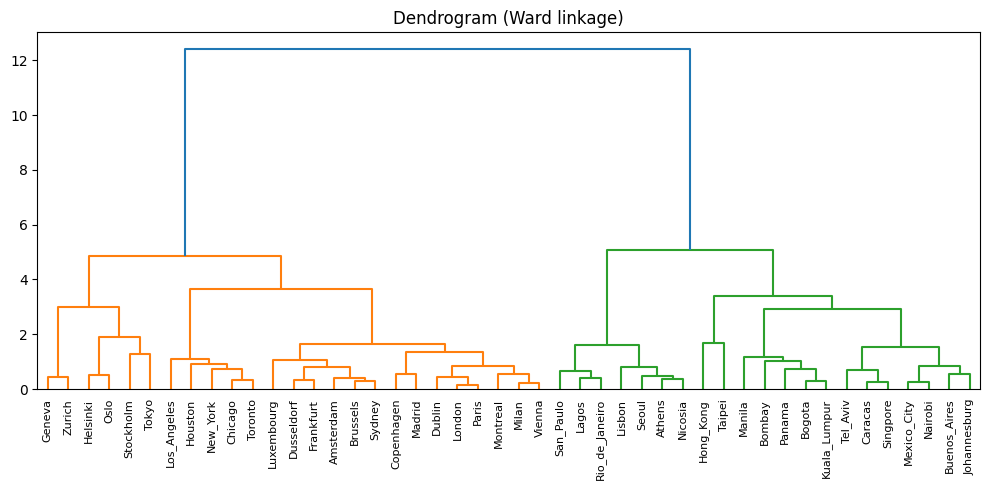

In [ ]:
# Построим дефолтную дендрограмму
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked, labels=cities, leaf_rotation=90)
plt.title("Dendrogram (Ward linkage)")
plt.tight_layout()
plt.show()
# Видим неплохое разделение на города "первого" и "второго-третьего" мира, но два кластера мало


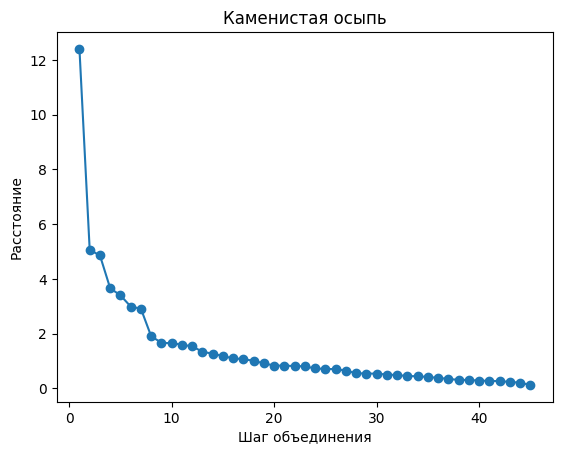

In [ ]:
# 6. График каменистая осыпь
dist = linked[:, 2]
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.plot(idxs, dist_rev, marker='o')
plt.title('Каменистая осыпь')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние')
plt.show()
# Видим первый излом в расстоянии = 4, второй в расстоянии = 2

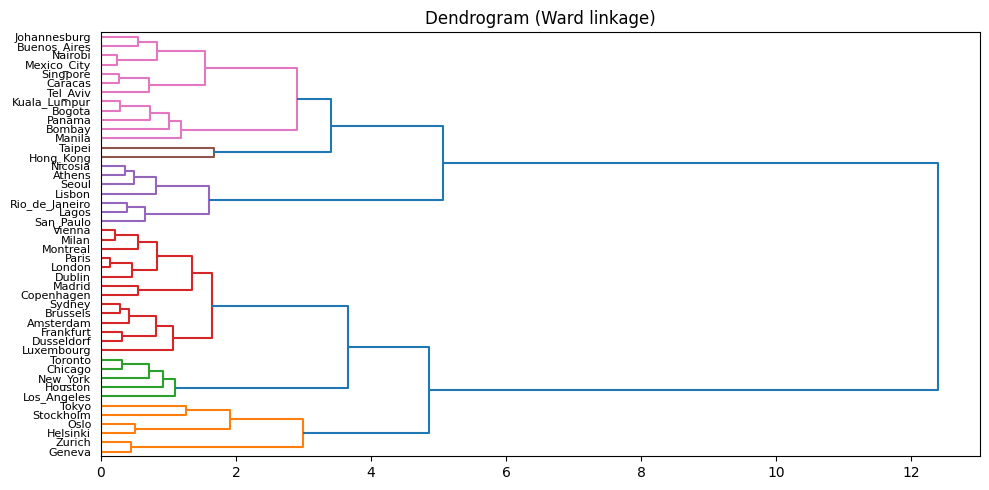

In [ ]:
# Построим дендрограмму для расстояния = 2
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked,
                labels=cities,
                color_threshold=3.3,
                orientation = "right",
                leaf_rotation=0.)
plt.title("Dendrogram (Ward linkage)")
plt.tight_layout()
plt.show()
#den2 = fcluster(linked, 2, criterion='distance')
#den3 = fcluster(linked, 2, criterion='maxclust')
#print(silhouette_score(X_scaled, den2))
#print(silhouette_score(X_scaled, den3))
# Много кластеров, один похож на выбросы

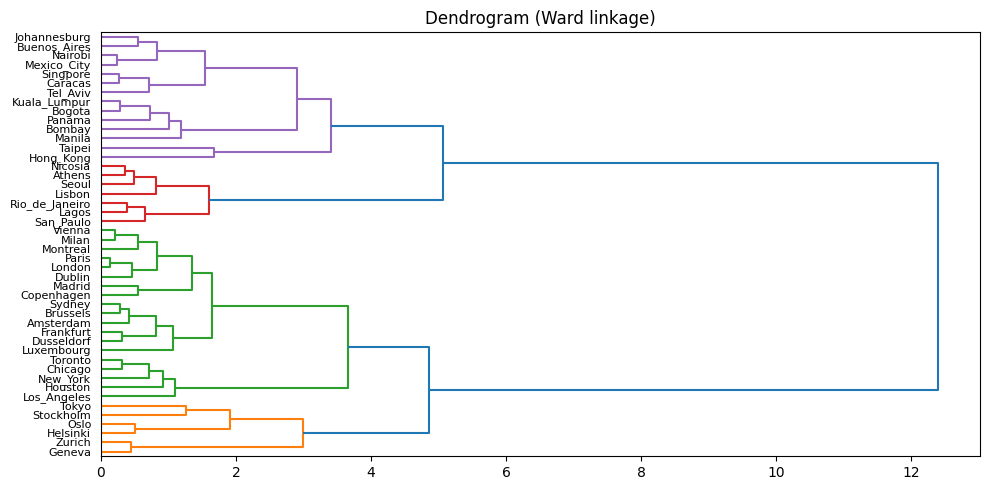

In [ ]:
# Построим дендрограмму для расстояния = 4
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked,
                labels=cities,
                color_threshold=4,
                orientation = "right",
                leaf_rotation=0.)
plt.title("Dendrogram (Ward linkage)")
plt.tight_layout()
plt.show()

In [ ]:
df['D_cluster'] = fcluster(linked, 4, criterion='distance')
print(np.unique(df['D_cluster'], return_counts=True)[1])
df[['D_cluster', 'Work', 'Price', 'Salary']].groupby('D_cluster').mean()
# Получили неплохие хорошо интерпретируемые кластеры

[ 6 19  7 14]


,Work,Price,Salary
D_cluster,,,
1,1780.500000,108.550000,71.300000
2,1792.000000,77.526316,55.157895
3,1798.857143,50.942857,19.214286
4,2082.357143,53.121429,14.914286


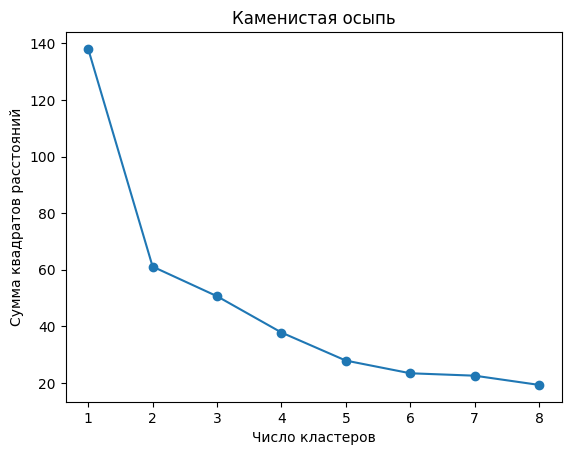

In [ ]:
# 2. KMeans
K = range(1, 9)

# Вычисляем значения критерия качества для разного числа кластеров
models = [KMeans(n_clusters=k, random_state=42).fit(X_scaled) for k in K]
dist = [model.inertia_ for model in models]

# Строим график каменистая осыпь
plt.plot(K, dist, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Каменистая осыпь')
plt.show()
# После двух кластеров расстояния мало меняются

In [ ]:
# KMeans: k = 2..8, считаем silhouette
k_scores = []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    lbl = km.labels_
    sil = silhouette_score(X_scaled, lbl)
    k_scores.append((k, float(sil)))
print("KMeans silhouette scores:")
for k in k_scores:
    print(k)
best_k = max(k_scores, key=lambda x: x[1])[0]
print("Best k by silhouette:", best_k)
# Оценки подтверждают что k = 2 лучшее

KMeans silhouette scores:
(2, 0.47049928674558456)
(3, 0.37807853585555085)
(4, 0.3364565375643669)
(5, 0.3688699508269114)
(6, 0.39468833740252235)
(7, 0.25491557153960526)
(8, 0.28750967841099834)
Best k by silhouette: 2


In [ ]:
#Посмотрим 6 кластеров
df['KM_cluster'] = KMeans(n_clusters=6, random_state=42).fit(X_scaled).labels_
print(np.unique(df['KM_cluster'], return_counts=True)[1])
df[['KM_cluster', 'Work', 'Price', 'Salary']].groupby('KM_cluster').mean()
#Интересно, но некоторые кластеры слишком малы

[ 8  6 14 12  2  4]


,Work,Price,Salary
KM_cluster,,,
0,2146.875000,48.762500,12.412500
1,1990.833333,77.233333,55.316667
2,1732.000000,78.135714,53.614286
3,1868.750000,52.158333,17.458333
4,1874.000000,97.950000,95.150000
5,1733.750000,113.850000,59.375000


In [ ]:
df[['City','KM_cluster']].sort_values(by='KM_cluster')

,City,KM_cluster
3,Bombay,0
2,Bogota,0
6,Caracas,0
14,Hong_Kong,0
24,Manila,0
17,Kuala_Lumpur,0
37,Singpore,0
32,Panama,0
21,Los_Angeles,1
29,New_York,1


In [ ]:
df['KM_cluster'] = KMeans(n_clusters=best_k, random_state=42).fit(X_scaled).labels_
print(np.unique(df['KM_cluster'], return_counts=True)[1])
df[['KM_cluster', 'Work', 'Price', 'Salary']].groupby('KM_cluster').mean()
# Лучше чем 2 кластера нам не получить

[21 25]


,Work,Price,Salary
KM_cluster,,,
0,1987.857143,52.395238,16.347619
1,1789.240000,84.972000,59.032000


In [ ]:
# 3. DBSCAN


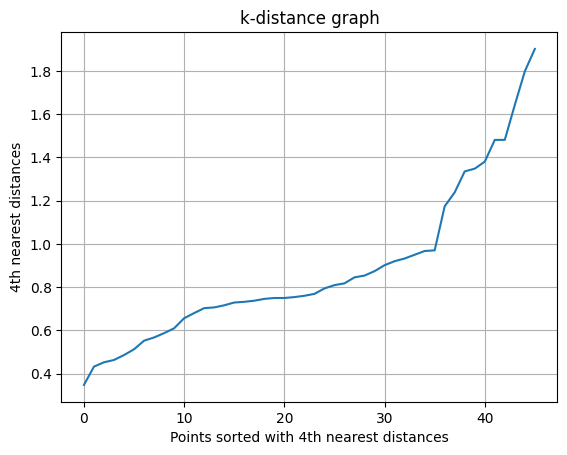

In [ ]:
minpts = 4

# Вычисляем попарные евклидовы расстояния
D = distance.cdist(X_scaled, X_scaled, 'euclidean')

# Сортируем расстояния для каждой точки
D_sorted = np.sort(D, axis=1)
kD = D_sorted[:, minpts]

# Строим график k-distance
plt.plot(np.sort(kD))
plt.title('k-distance graph')
plt.xlabel(f'Points sorted with {minpts}th nearest distances')
plt.ylabel(f'{minpts}th nearest distances')
plt.grid(True)
plt.show()
# Оптимальный eps лежит где-то между 0.8 и 1.3

In [63]:
eps_1 = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.25, 1.5, 1.75, 2, 2.25]
min_samples_1 = [3, 4, 5, 6, 7 , 8 , 9]
sil_avg = []
max_value = [0, 0, 0, -1]

for i in range(len(eps_1)):
    for j in range(len(min_samples_1)):

        db = DBSCAN(min_samples = min_samples_1[j], eps = eps_1[i], algorithm= 'brute').fit(X_scaled)

        labels = db.labels_

        # Число кластеров, после отбрасывания выбросов
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

        # Число выбросов
        # n_noise_ = list(labels).count(-1)

        if n_clusters_ > 1:
            silhouette_avg = silhouette_score(X_scaled, labels)
            if silhouette_avg > max_value[3]:
                max_value=(eps_1[i], min_samples_1[j], n_clusters_, silhouette_avg)
            sil_avg.append(silhouette_avg)

print("epsilon=", max_value[0],
      "\nmin_sample=",max_value[1],
      "\nnumber of clusters=", max_value[2],
      "\naverage silhouette score= %.4f" % max_value[3])


epsilon= 0.75 
min_sample= 3 
number of clusters= 2 
average silhouette score= 0.3778


In [65]:
eps_1 = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.25, 1.5, 1.75, 2, 2.25]
min_samples_1 = [3, 4, 5,6,7,8]
db_avg = []
max_value_db = [0, 0, 0, -1]

for i in range(len(eps_1)):
    for j in range(len(min_samples_1)):

        db = DBSCAN(min_samples = min_samples_1[j], eps =eps_1[i], algorithm= 'brute').fit(X_scaled)

        labels = db.labels_

        # Число кластеров, после отбрасывания выбросов
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

        # Число выбросов
        # n_noise_ = list(labels).count(-1)

        if n_clusters_ > 1 and (n_clusters_ == 3 or n_clusters_ == 4):
            db = davies_bouldin_score(X_scaled, labels)
            if db > max_value_db[3]:
                max_value_db=(eps_1[i], min_samples_1[j], n_clusters_, db)
            db_avg.append(db)

print("epsilon=", max_value_db[0],
      "\nmin_sample=",max_value_db[1],
      "\nnumber of clusters=", max_value_db[2],
      "\naverage davies bouldin score= %.4f" % max_value_db[3])

epsilon= 0.5 
min_sample= 3 
number of clusters= 3 
average davies bouldin score= 2.1751


In [59]:
eps_1 = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.25, 1.5, 1.75, 2, 2.25]
min_samples_1 = [3, 4, 5, 6, 7 , 8 , 9]
sil_avg = []
max_value = [0, 0, 0, -1]

for i in range(len(eps_1)):
    for j in range(len(min_samples_1)):

        db = DBSCAN(min_samples = min_samples_1[j], eps = eps_1[i], metric = 'cityblock', algorithm= 'brute').fit(X_scaled)

        labels = db.labels_

        # Число кластеров, после отбрасывания выбросов
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

        # Число выбросов
        # n_noise_ = list(labels).count(-1)

        if n_clusters_ > 1:
            silhouette_avg = silhouette_score(X_scaled, labels)
            if silhouette_avg > max_value[3]:
                max_value=(eps_1[i], min_samples_1[j], n_clusters_, silhouette_avg)
            sil_avg.append(silhouette_avg)

print("epsilon=", max_value[0],
      "\nmin_sample=",max_value[1],
      "\nnumber of clusters=", max_value[2],
      "\naverage silhouette score= %.4f" % max_value[3])

epsilon= 1.25 
min_sample= 5 
number of clusters= 2 
average silhouette score= 0.3778


In [66]:
df['DB_cluster'] = DBSCAN(eps=max_value[0], min_samples=max_value[1], algorithm= 'brute').fit(X_scaled).labels_
print(np.unique(df['DB_cluster'], return_counts=True)[1])
df[['DB_cluster', 'Work', 'Price', 'Salary']].groupby('DB_cluster').mean()
# Получили опять два кластера бедных и богатых городов, а также выбросы

[ 8 19 19]


,Work,Price,Salary
DB_cluster,,,
-1,1900.375000,99.925000,61.262500
0,1792.000000,77.526316,55.157895
1,1959.210526,50.115789,14.789474


In [67]:
df[['City','DB_cluster']].sort_values(by='DB_cluster')

,City,DB_cluster
14,Hong_Kong,-1
12,Geneva,-1
13,Helsinki,-1
31,Oslo,-1
40,Taipei,-1
42,Tokyo,-1
45,Zurich,-1
38,Stockholm,-1
9,Dublin,0
10,Dusseldorf,0


In [68]:
# Посмотрим 4 кластера
df['DB_cluster'] = DBSCAN(eps=max_value_db[0], min_samples=max_value_db[1], algorithm= 'brute').fit(X_scaled).labels_
print(np.unique(df['DB_cluster'], return_counts=True)[1])
df[['DB_cluster', 'Work', 'Price', 'Salary']].groupby('DB_cluster').mean()

[23 14  3  6]


,Work,Price,Salary
DB_cluster,,,
-1,1923.434783,71.995652,39.008696
0,1771.928571,76.078571,53.750000
1,1819.666667,53.333333,30.466667
2,1995.166667,57.266667,13.000000


In [69]:
df[['City','DB_cluster']].sort_values(by='DB_cluster')

,City,DB_cluster
3,Bombay,-1
2,Bogota,-1
14,Hong_Kong,-1
15,Houston,-1
12,Geneva,-1
13,Helsinki,-1
8,Copenhagen,-1
31,Oslo,-1
24,Manila,-1
23,Madrid,-1


In [ ]:
df.to_csv("econom_cities_clusters.csv", index=False)